# Phase 2 — Dataset Preparation
Create reproducible leakage-safe splits and training-only augmentation.

In [1]:
from pathlib import Path
import hashlib, random
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Load canonical data
Use the 300×300 `casting_data` collection and deduplicate before splitting.

In [2]:
SEED, IMG_SIZE = 42, (224, 224)
root = Path.cwd() / 'casting_data' / 'casting_data'
label_map = {'ok_front': 'OK', 'def_front': 'Defective'}
paths = sorted(root.rglob('*.jpeg'))
df = pd.DataFrame({'path': [str(p) for p in paths], 'label': [label_map[p.parent.name] for p in paths]})
print(f'Canonical images: {len(df):,}')

Canonical images: 7,348


## Remove exact duplicates
Hashing is performed before any split to prevent duplicate leakage.

In [3]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''): h.update(chunk)
    return h.hexdigest()
df['sha256'] = df['path'].map(sha256)
df = df.drop_duplicates('sha256', keep='first').reset_index(drop=True); print(f'Unique images: {len(df):,}')

Unique images: 7,284


## Create reproducible stratified splits
The same seed produces the same train, validation, and test assignments.

In [4]:
train, holdout = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
val, test = train_test_split(holdout, test_size=0.50, stratify=holdout['label'], random_state=SEED)
train, val, test = train.copy(), val.copy(), test.copy()
train['split'], val['split'], test['split'] = 'train', 'validation', 'test'
splits = pd.concat([train, val, test], ignore_index=True)
display(splits.groupby(['split','label']).size().rename('images').to_frame())

images
split      label            
test       Defective     632
           OK            461
train      Defective    2947
           OK           2151
validation Defective     632
           OK            461

## Verify leakage and balance
No hash may occur in more than one final split.

In [5]:
hash_split_counts = splits.groupby('sha256')['split'].nunique()
leakage = int((hash_split_counts > 1).sum())
distribution = splits.groupby(['split','label']).size().unstack(fill_value=0)
print(f'Cross-split duplicate hashes: {leakage}')
display(distribution)

Cross-split duplicate hashes: 0


label,Defective,OK
split,,
test,632,461
train,2947,2151
validation,632,461


## Define preprocessing and training-only augmentation
Resize and scale every split; random transforms are applied only to training samples.

In [6]:
def preprocess(path):
    with Image.open(path) as im: im = im.convert('RGB').resize(IMG_SIZE)
    return np.asarray(im, dtype=np.float32) / 255.0
def augment_train(image, rng):
    if rng.random() < 0.5: image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
    image = image.rotate(rng.uniform(-10, 10), fillcolor=(128, 128, 128))
    return ImageEnhance.Brightness(image).enhance(rng.uniform(0.9, 1.1))

## Display preprocessed examples
Validation and test samples use preprocessing only; augmentation is demonstrated for training samples.

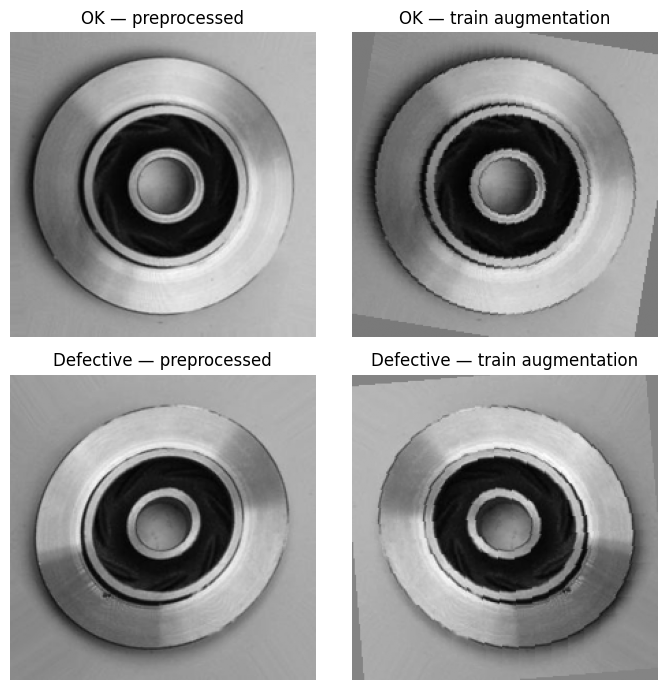

In [7]:
rng = random.Random(SEED); examples = []
for label in ['OK', 'Defective']:
    path = Path(train.loc[train['label'].eq(label), 'path'].sort_values().iloc[0])
    with Image.open(path) as im: base = im.convert('RGB').resize(IMG_SIZE); aug = augment_train(base.copy(), rng)
    examples.extend([(label + ' — preprocessed', np.asarray(base) / 255.0), (label + ' — train augmentation', np.asarray(aug) / 255.0)])
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for ax, (title, image) in zip(axes.ravel(), examples): ax.imshow(image); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.savefig('phase2_preprocessed_samples.png', dpi=160); plt.show()

## Save the reproducible manifest
The manifest records the final split, label, and content hash.

In [8]:
splits.to_csv('phase2_clean_splits.csv', index=False)
config = {'seed': SEED, 'image_size': IMG_SIZE, 'train_augmentation_only': True, 'canonical_source': str(root)}
pd.Series(config).to_json('phase2_preprocessing_config.json')
print(f'Saved {len(splits):,} unique records; leakage groups: {leakage}')
print('Phase 2 complete; ready for Phase 3.')

Saved 7,284 unique records; leakage groups: 0
Phase 2 complete; ready for Phase 3.
